In [ ]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import json
import matplotlib.pyplot as plt
import numpy as np
import copy

from utils.data_reader import load_and_prepare_time_series_data
from utils.trainer import Trainer
from utils.evaluator import Evaluator
from models.baseline_models import LSTMModel, BiLSTMModel, GRUModel
from models.custom_models import MGSSMsModel, ExtendedMGSSMsModel

In [3]:
country_codes = ['US', 'IN', 'BR', 'FR', 'DE',
                 'GB', 'RU', 'IT', 'TR', 'ES',
                 'VN', 'AR', 'AU', 'AT', 'BD',
                 'BE', 'BG', 'CA', 'CL', 'CN',
                 'CU', 'DK', 'FI', 'GE', 'GR',
                 'ID', 'JP', 'JO', 'KE', 'KR',
                 'LR', 'MY','ML', 'MX', 'NL',
                 'NO', 'PH','SE', 'CH', 'TH']

selected_country_codes = [country_codes[0]]
# Fetch and prepare the data for each country code
with open("/home/theppawan/nn-models/data/COVID19_url_data.json", "r") as f:
    dataset = json.load(f)

train_loader_dist = {}
val_loader_dist = {}
test_loader_dist = {}
scaler_dist = {}
for key in selected_country_codes:
    train_loader, val_loader, test_loader, scaler = load_and_prepare_time_series_data(
        filepath_or_url = dataset['region'].format(region=key),
        target_column="cumulative_confirmed",
        date_column="date",
        seq_length=14,
        batch_size=64,
        train_split=0.8,
        val_split=0.1,
        fill_missing=True)
    train_loader_dist[key] = train_loader
    val_loader_dist[key] = val_loader
    test_loader_dist[key] = test_loader
    scaler_dist[key] = scaler

# Setup model configurations
model_config_dict = {
    "Baseline LSTM": LSTMModel(input_size=1, hidden_size=64, num_layers=1, output_size=1),
    "Baseline BiLSTM": BiLSTMModel(input_size=1, hidden_size=64, num_layers=1, output_size=1),
    "Baseline GRU": GRUModel(input_size=1, hidden_size=64, num_layers=1, output_size=1),
    "MGSSMs": MGSSMsModel(input_size=1, hidden_size=64, num_layers=1, output_size=1, gate_size=32),
    "ExtendedMGSSMs": ExtendedMGSSMsModel(input_size=1, hidden_size=48, num_layers=1, output_size=1, gate_size=32, p=2)
}

Fetching data from: https://storage.googleapis.com/covid19-open-data/v3/location/US.csv
Sorting data chronologicall by column: date
Succesfully loaded 991 sequential data points.
Prepared:
    --> Training batches: 13
    --> Validation batches: 2
    --> Testing batches: 2


In [4]:
model_trained = []
for model in model_config_dict.values():
    print(f"Training model: {model.__class__.__name__}")
    trainer = Trainer(
        model=model,
        criterion=nn.MSELoss(),
        optimizer=optim.Adam(model.parameters(), lr=0.001),
        device="cpu"
    )
    for key in selected_country_codes:
        train_loader = train_loader_dist[key]
        val_loader = val_loader_dist[key]
        print(f"Training on country code: {key}")

        trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000, patience=50, label=key)

Training model: LSTMModel
Training on country code: US
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 141 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_LSTMModel_US.pth
Training model: BiLSTMModel
Training on country code: US
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 137 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_BiLSTMModel_US.pth
Training model: GRUModel
Training on country code: US
Starting training on device: cpu


...

Early stopping triggered after 57 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_GRUModel_US.pth
Training model: MGSSMsModel
Training on country code: US
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 89 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_MGSSMsModel_US.pth
Training model: ExtendedMGSSMsModel
Training on country code: US
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 70 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_ExtendedMGSSMsModel_US.pth


In [5]:
def plot_predictions(model, test_loader, scaler):
    model.eval()
    
    actuals = []
    predictions = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            preds = model(batch_x)
            actuals.extend(batch_y.cpu().numpy().flatten())
            predictions.extend(preds.cpu().numpy().flatten())

    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    actuals = scaler.inverse_transform(np.array(actuals).reshape(-1, 1))
            
    # Plotting the validation data
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label="Actual COVID-19 Cases", color="blue")
    plt.plot(predictions, label="Model Predictions", color="red", linestyle="--")
    plt.title(f"{model.__class__.__name__} Forecasting on COVID-19 Open Data")
    plt.xlabel("Days")
    plt.ylabel("Cumulative Confirmed Cases")
    plt.legend()
    plt.grid(True)
    plt.show()

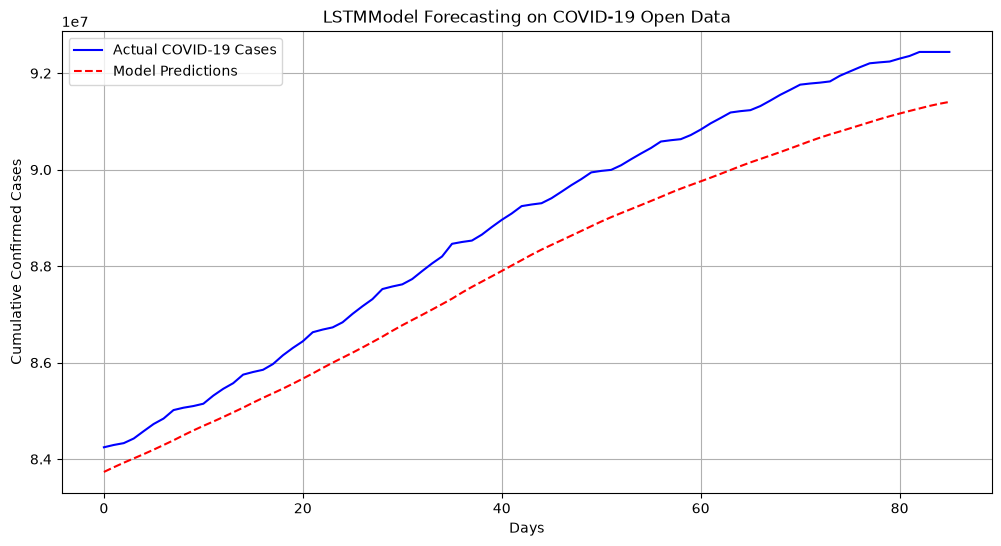

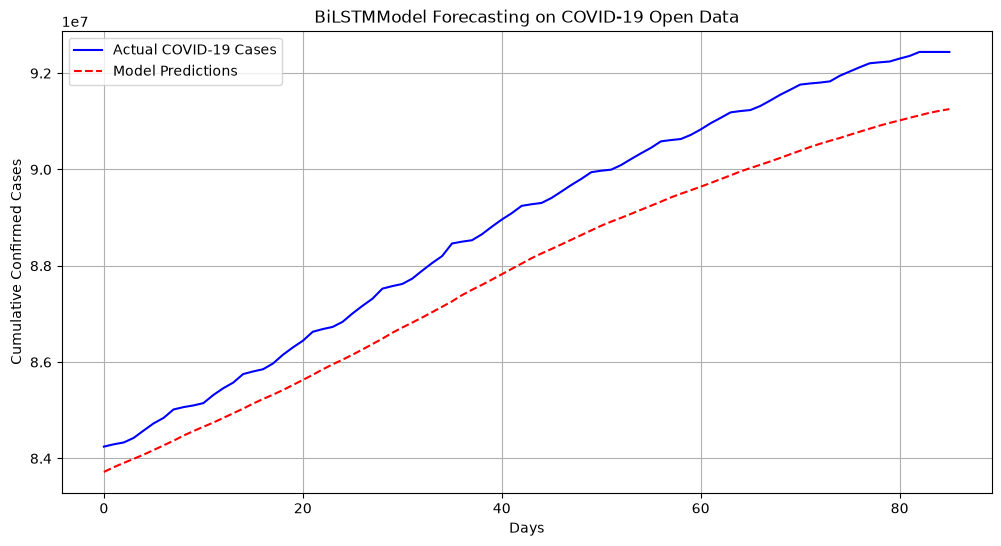

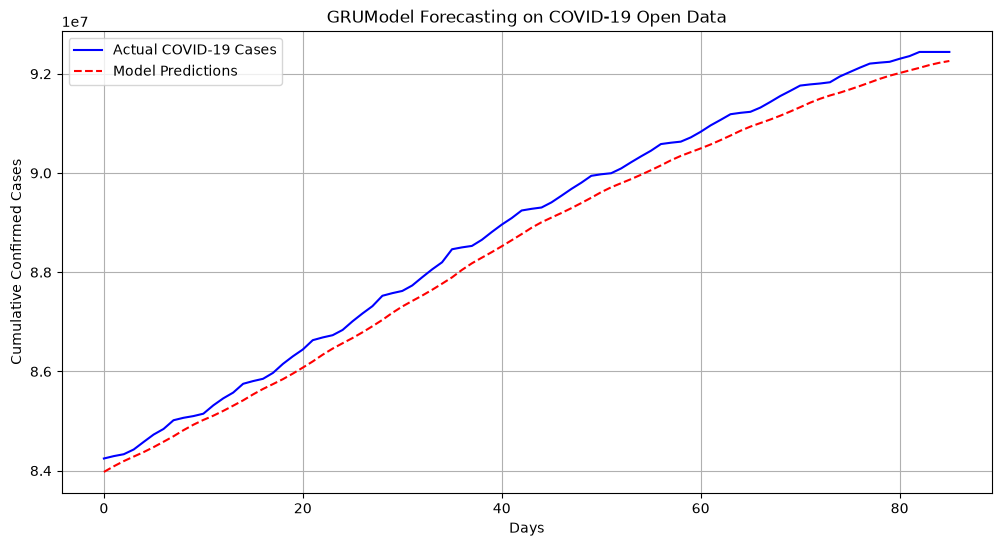

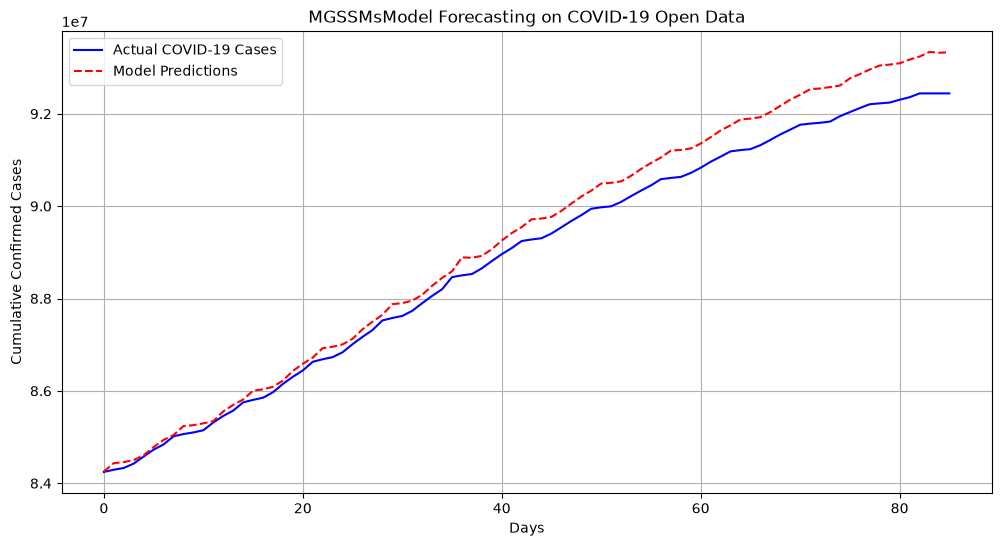

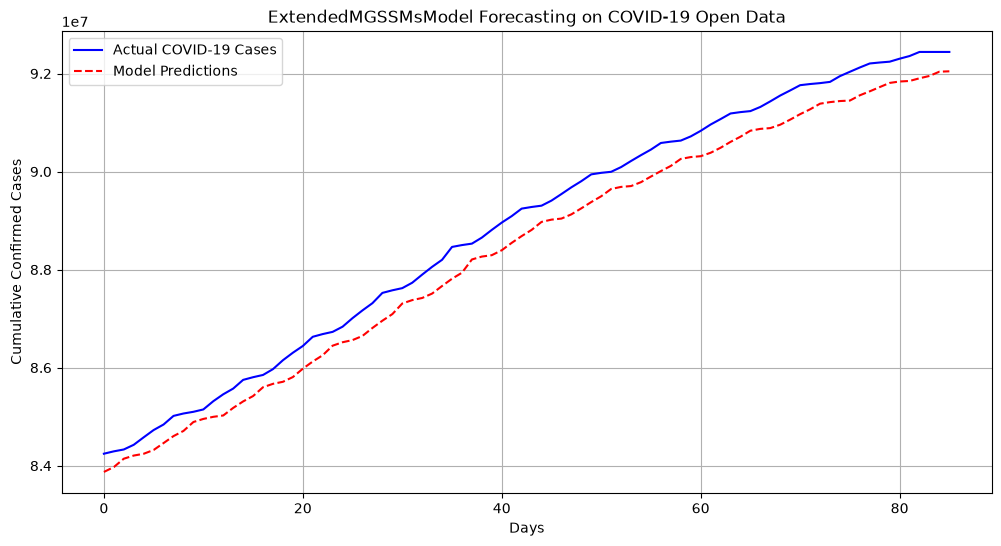

In [6]:
code = 'US'
for model_config in model_config_dict.values():
    # analyze the model from the checkpoint
    model_config.load_state_dict(torch.load(f"checkpoints/best_{model_config.__class__.__name__}_{code}.pth"))
    plot_predictions(model_config, test_loader_dist[code], scaler_dist[code])

## Analysis

In [13]:
trained_model_dict = {key: {} for key in selected_country_codes}
# loading the checkpointed models
for model_name, model_config in model_config_dict.items():
    # analyze the model from the checkpoint
    for key in selected_country_codes:
        country_specific_model = copy.deepcopy(model_config)
        country_specific_model.load_state_dict(torch.load(f"checkpoints/best_{model_config.__class__.__name__}_{key}.pth"))
        trained_model_dict[key][model_name] = country_specific_model

evaluator = Evaluator()
for key in selected_country_codes:
    evaluator.compare_models(trained_model_dict[key], test_loader_dist[key], scaler_dist[key])

Evaluating model: Baseline LSTM...
Evaluating model: Baseline BiLSTM...
Evaluating model: Baseline GRU...
Evaluating model: MGSSM...
Evaluating model: MGSSMs...
Evaluating model: ExtendedMGSSMs...


In [14]:
performance_data = evaluator.build_performance_dataframe(nested_models_dict=trained_model_dict, data_loaders_dict=test_loader_dist, scalers_dict=scaler_dist, target_metric="MSE")
performance_data

Evaluating models for dataset: US...


,Baseline LSTM,Baseline BiLSTM,Baseline GRU,MGSSM,MGSSMs,ExtendedMGSSMs
US,3.100602e+11,2.800748e+11,6.418463e+09,2.625478e+10,1.224463e+11,1.541640e+11


In [15]:
friedman_statistic, p_value = evaluator.friedman_test(performance_data)
p_value

np.float64(0.4158801869955079)

In [16]:
evaluator.holm_bonferroni_posthoc(performance_data, control_model="ExtendedMGSSMs", alpha=0.05, metric_is_loss=True)

,unadjusted p-value,Step (i),Holm threshold,Holm adjusted p-value,reject null hypothesis
baseline model,,,,,
Baseline LSTM,0.5,1,0.010000,1.0,False
Baseline BiLSTM,0.5,2,0.012500,1.0,False
Baseline GRU,1.0,3,0.016667,1.0,False
MGSSM,1.0,4,0.025000,1.0,False
MGSSMs,1.0,5,0.050000,1.0,False
